# Capstone — When does physics emerge in CaloDiffusion?

**Read `START_HERE.md` first** (the idea) and skim `JUMPING_OFF_POINTS.md` (the plan &
deliverables). This notebook gets you to **M0** (tools working) and scaffolds the **core**
measurement — the emergence curves and lock-in steps of four observables along the x̂₀
trajectory. The physics (the observables, the lock-in, the interpretation) is left to you as
`TODO`s on purpose.

## 0 · Setup

In [1]:
import sys, os
try:
    import calodiff_probe as cp          # works when run from this folder
except ModuleNotFoundError:              # or from the repo root
    sys.path.insert(0, 'capstone/calodiffusion')
    import calodiff_probe as cp
import numpy as np, torch, matplotlib.pyplot as plt
print('running on:', cp.DEVICE)   # 'cuda' on the GPU box, else 'cpu' (generation is slow on cpu)

running on: cuda


## 1 · Warm-up → **M0** (worked — just run these)

Get the tools in your hands before the real work. Nothing here is graded; it de-risks the API.

### 1a · What a shower looks like
A real shower as a **layer × radius** heatmap (summed over the angular axis).



 Model: 

Event start, stop:  0 16
dset 2


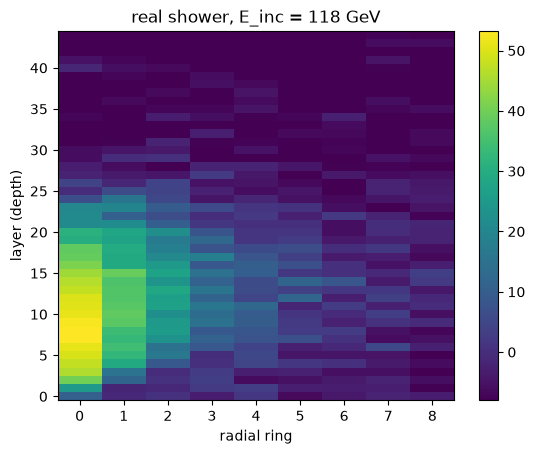

In [2]:
model = cp.load_model('electron')
x, E, E_inc = cp.load_showers('electron', n=16)
grid = cp.regular_grid(model, x)          # (16, layer=45, angular=16, radial=9)
plt.imshow(grid[0].sum(axis=1), aspect='auto', origin='lower')
plt.xlabel('radial ring'); plt.ylabel('layer (depth)')
plt.title(f'real shower, E_inc = {E_inc[0]:.0f} GeV'); plt.colorbar(); plt.show()

### 1b · The forward (noising) process
The model learns to *reverse* this. Watch a shower dissolve into noise.

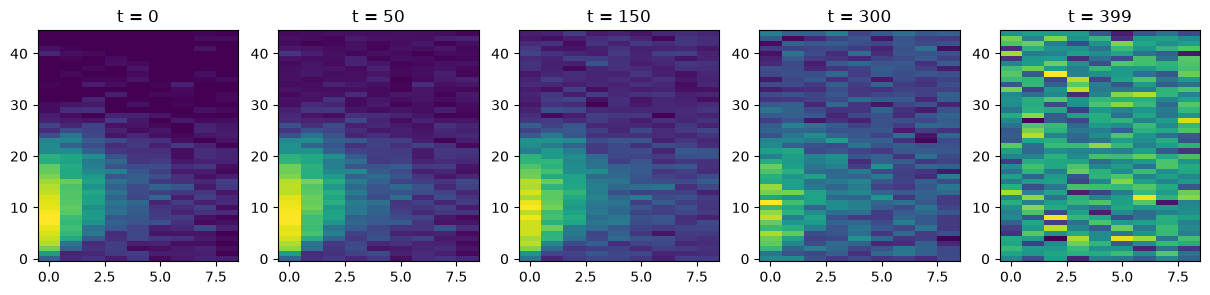

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, t in zip(axes, [0, 50, 150, 300, 399]):
    x_t, _ = cp.noise_at(model, x, t)
    ax.imshow(cp.regular_grid(model, x_t)[0].sum(1), aspect='auto', origin='lower')
    ax.set_title(f't = {t}')
plt.show()

### 1c · Does the model actually denoise?
It predicts the noise added at step `t`; the prediction should correlate with the truth (~0.9).

In [4]:
x_t, eps = cp.noise_at(model, x, t=100)
eps_hat  = cp.predict_noise(model, x_t, E, t=100)
corr = torch.corrcoef(torch.stack([eps_hat.flatten(), eps.flatten()]))[0, 1]
print(f'corr(predicted, true noise) = {corr:.3f}   # ~0.9 = the model works')

corr(predicted, true noise) = 0.908   # ~0.9 = the model works


---
## 2 · The core — emergence curves & lock-in  → **M1 / M2**

As the model builds a shower from noise, it produces at every step a running guess of the
finished shower: **x̂₀** (START_HERE §2). We compute physics on x̂₀ **in physical units** at
each step and ask: *in what order do the observables settle?*

### 2a · Get the x̂₀ trajectory (worked)
⚠️ Generation is slow on CPU — keep `n` small here; move to the **GPU** for real runs.
`x0s` is the per-step list of x̂₀ frames (index 0 = noisiest ... last = clean).

In [5]:
n = 8
E_inc_gev = [50.] * n                     # fixed energy for the core measurement
E_cond = cp.encode_energy('electron', E_inc_gev)
x_final, xs, x0s = cp.sample(model, E_cond, debug=True)
print(f'{len(x0s)} trajectory frames, each {np.asarray(x0s[0]).shape}')
# convert one frame to physical GeV to see the shape you'll work with:
print('one frame -> physical grid:', cp.to_physical(model, x0s[-1], E_inc_gev).shape,
      '= (n, layer, angular, radial)')

SAMPLE ALGO : ddpm
Time for sampling 8 events is 5.2435243129730225 seconds
398 trajectory frames, each (8, 1, 45, 16, 9)
dset 2
one frame -> physical grid: (8, 45, 16, 9) = (n, layer, angular, radial)


### 2b · The four observables  ⟵ **your job**
Each takes a physical grid `g` of shape `(N, layer, angular, radial)` and returns one number
**per shower** (an array of length N). One is done as the pattern; write the other three.

- `total_energy` — sum of all cell energies *(worked, shows the pattern)*
- `depth` — energy-weighted **mean layer index** (how deep the shower peaks)
- `radial_spread` — energy-weighted **RMS radius** (how wide it is)
- `occupancy` — fraction of cells above a **fixed** threshold `ecut` *(use `model.config['ECUT']`)*

In [6]:
def total_energy(g):                       # (N, layer, ang, rad) -> (N,)
    return g.sum(axis=(1, 2, 3))

def depth(g):
    layer_energy = g.sum(axis=(2,3))
    layers = np.arange(g.shape[1])
    total_energy = layer_energy.sum(axis=1)
    return (layer_energy * layers).sum(axis=1) / total_energy

def radial_spread(g):
    radial_energy = g.sum(axis=(1,2))
    r = np.arange(g.shape[3])
    total_energy = radial_energy.sum(axis=1)
    mean_r = (radial_energy * r).sum(axis=1) / total_energy
    r_diff_sq = (r[np.newaxis, :] - mean_r[:, np.newaxis])**2
    var = (r_diff_sq * radial_energy).sum(axis=1) / total_energy
    return np.sqrt(var)

def occupancy(g, ecut):
    hits = (g > ecut).sum(axis=(1,2,3))
    total_cells = g.shape[1] * g.shape[2] * g.shape[3]
    return hits/total_cells

### 2c · Build the emergence curves  ⟵ **your job**
Walk the trajectory, compute each observable on x̂₀ (physical units) at every step, and
**normalise each curve to its final value** (the last frame). Then plot all four vs step.

*Expectation to test:* total energy & depth settle **early** (coarse), radial spread &
occupancy **late** (fine). Is that what you see?

dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2

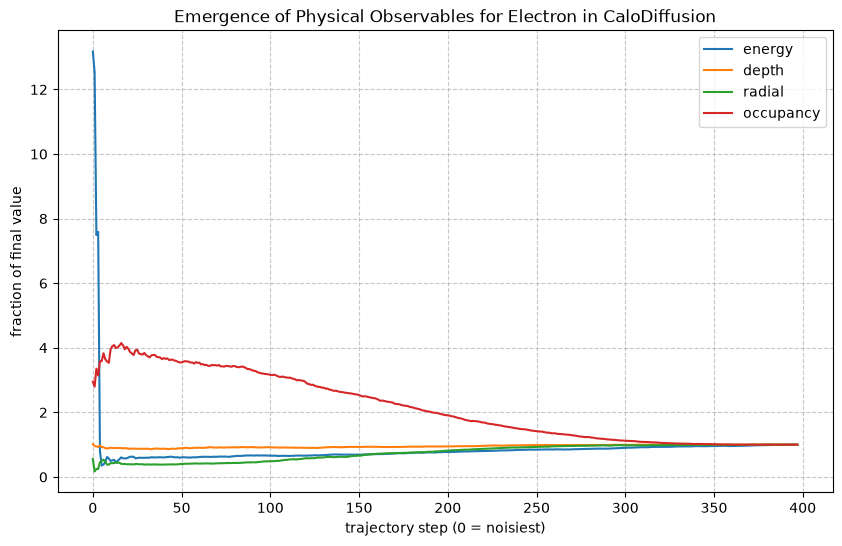

In [13]:
ecut = model.config['ECUT']
obs_fns = {'energy': total_energy, 'depth': depth,
           'radial': radial_spread, 'occupancy': lambda g: occupancy(g, ecut)}
curves = {name: [] for name in obs_fns}
for x0 in x0s:
    g = cp.to_physical(model, x0, E_inc_gev)      # (n, layer, ang, rad) in GeV
    for name, fn in obs_fns.items():
        curves[name].append( np.median(fn(g)) )

# TODO: normalise each curve to its final value, then plot vs step.
plt.figure(figsize=(10,6))
for name, vals in curves.items():
     vals = np.array(vals) / vals[-1]
     plt.plot(vals, label=name)
plt.xlabel('trajectory step (0 = noisiest)'); plt.ylabel('fraction of final value')
plt.title('Emergence of Physical Observables for Electron in CaloDiffusion')
plt.grid(True, linestyle='--', alpha=0.7); plt.legend(); plt.savefig('Emergence_of_Physical_Observables_electron.png',dpi = 300) 
plt.show()

### 2d · The lock-in step + table  ⟵ **your job**
Define the **lock-in step** of an observable = the first step after which its (normalised)
curve stays within ~10% of its final value. Compute it for all four and make a small table.

*This scalar is the result* — it turns 'look at this plot' into a number you can compare
across particles (the nice-to-have).

In [14]:
def lock_in_step(norm_curve, tol=0.1):
    norm_curve = np.array(norm_curve)
    out_of_tol = np.abs(norm_curve - 1) > tol
    out_indices = np.where(out_of_tol)[0]
    if len(out_indices) == 0 :
        return 0
    lock_step = out_indices[-1] + 1
    return min(lock_step , len(norm_curve) - 1)

print(f"{'Observable':<15} | {'Lock-in Step':<12}")
print("-" * 30)
lock_in_results = {}
for name, vals in curves.items():
    # Re-normalize the curve to its final value
    norm_curve = np.array(vals) / vals[-1]
    # Calculate the lock-in step using the default 10% (0.1) tolerance
    step = lock_in_step(norm_curve, tol=0.1)
    lock_in_results[name] = step
    print(f"{name:<15} | {step:<12}")
        

Observable      | Lock-in Step
------------------------------
energy          | 299         
depth           | 127         
radial          | 231         
occupancy       | 308         


## Comparing the Lock-in Steps and Emergence Plots for Electrons, Photons and Pions

### The Main Functions and Lock-in Steps

In [27]:
def total_energy(raw):
    raw_flat = raw.reshape(raw.shape[0],-1)
    return raw_flat.sum(axis=1)

def depth(g):
    layer_energy = g.sum(axis=(2,3))
    layers = np.arange(g.shape[1])
    total_energy = layer_energy.sum(axis=1)
    return (layer_energy * layers).sum(axis=1) / total_energy

def radial_spread(g):
    radial_energy = g.sum(axis=(1,2))
    r = np.arange(g.shape[3])
    total_energy = radial_energy.sum(axis=1)
    mean_r = (radial_energy * r).sum(axis=1) / total_energy
    r_diff_sq = (r[np.newaxis, :] - mean_r[:, np.newaxis])**2
    var = (r_diff_sq * radial_energy).sum(axis=1) / total_energy
    return np.sqrt(var)

def occupancy(raw , ecut):
    raw_flat = raw.reshape(raw.shape[0],-1)
    hits = (raw_flat > ecut).sum(axis=1)
    return hits / raw_flat.shape[1]

def lock_in_step(norm_curve, tol=0.1):
    norm_curve = np.array(norm_curve)
    out_of_tol = np.abs(norm_curve - 1) > tol
    out_indices = np.where(out_of_tol)[0]
    if len(out_indices) == 0 :
        return 0
    lock_step = out_indices[-1] + 1
    return min(lock_step , len(norm_curve) - 1)

### Pipeline : 

In [28]:
particle_types = ['electron', 'photon', 'pion']
n_showers = 64
matched_energy = 50.0
E_inc_gev = [matched_energy] * n_showers

master_results = {}
lock_in_table = {}

for particle in particle_types:
    model = cp.load_model(particle)
    ecut = model.config['ECUT']
    E_cond = cp.encode_energy(particle , E_inc_gev)
    _, _, x0s = cp.sample(model, E_cond, debug = True)
    curves = {'energy': [], 'depth' : [], 'radial': [], 'occupancy': []}
    for x0 in x0s:
        raw_physical = cp.to_physical(model, x0, E_inc_gev)
        
        if particle in ['photon','pion']:
            g = cp.regular_grid(model, raw_physical)
        else:
            g = raw_physical
            
        curves['energy'].append(np.median(total_energy(g)))
        curves['depth'].append(np.median(depth(g)))
        curves['radial'].append(np.median(radial_spread(g)))
        curves['occupancy'].append(np.median(occupancy(g, ecut)))
    master_results[particle] = curves
    particle_lock_ins = {}
    for name, vals in curves.items():
        norm_curve = np.array(vals) / vals[-1]
        particle_lock_ins[name] = lock_in_step(norm_curve, tol=0.1)
    lock_in_table[particle] = particle_lock_ins

print("\n" + "="*55)
print(f"{'Observable':<15} | {'Electron':<10} | {'Photon':<10} | {'Pion':<10}")
print("="*55)
for obs in ['energy', 'depth', 'radial', 'occupancy']:
    print(f"{obs:<15} | {lock_in_table['electron'][obs]:<10} | {lock_in_table['photon'][obs]:<10} | {lock_in_table['pion'][obs]:<10}")
print("="*55)



 Model: 

SAMPLE ALGO : ddpm
Time for sampling 64 events is 15.92553997039795 seconds
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
ds

/tmp/ipykernel_192/894883436.py:18: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(var)


dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11


#### Electron Emergence Plot

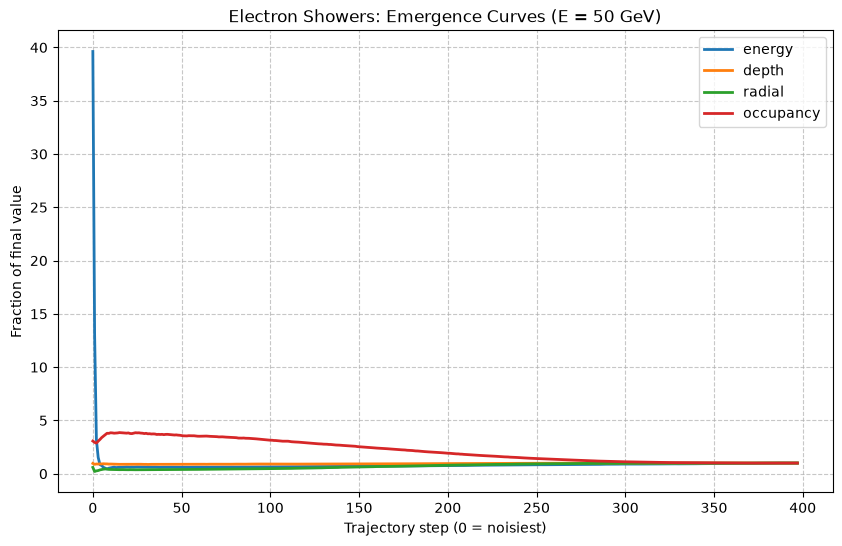

In [29]:
plt.figure(figsize=(10, 6))
for name, vals in master_results['electron'].items():
    norm_curve = np.array(vals) / vals[-1]
    plt.plot(norm_curve, label=name, linewidth=2)
    
plt.xlabel('Trajectory step (0 = noisiest)')
plt.ylabel('Fraction of final value')
plt.title('Electron Showers: Emergence Curves (E = 50 GeV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Emergence_Curve-Electron[50GeV].png',dpi = 300) 
plt.show()

#### Photon Emergence Plot

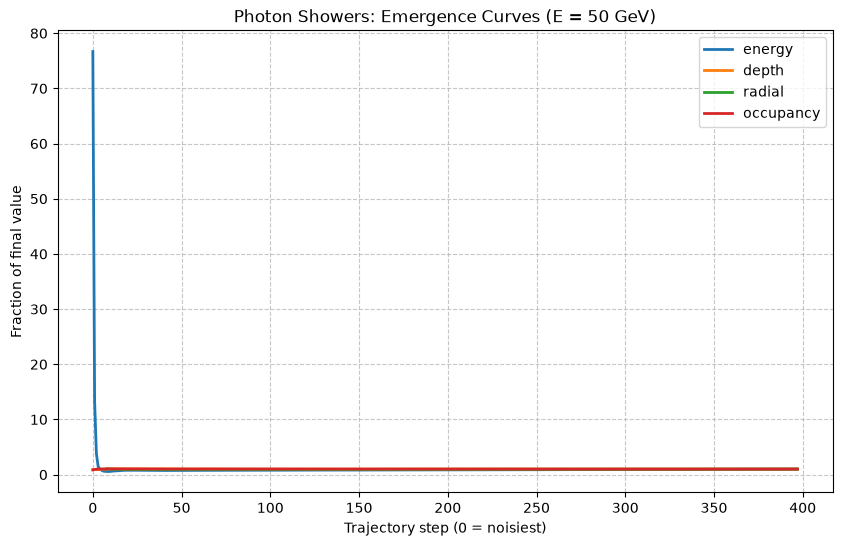

In [30]:
plt.figure(figsize=(10, 6))
for name, vals in master_results['photon'].items():
    norm_curve = np.array(vals) / vals[-1]
    plt.plot(norm_curve, label=name, linewidth=2)
    
plt.xlabel('Trajectory step (0 = noisiest)')
plt.ylabel('Fraction of final value')
plt.title('Photon Showers: Emergence Curves (E = 50 GeV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Emergence_Curve-Photon[50GeV].png',dpi = 300)
plt.show()

#### Pion Emergence Plot

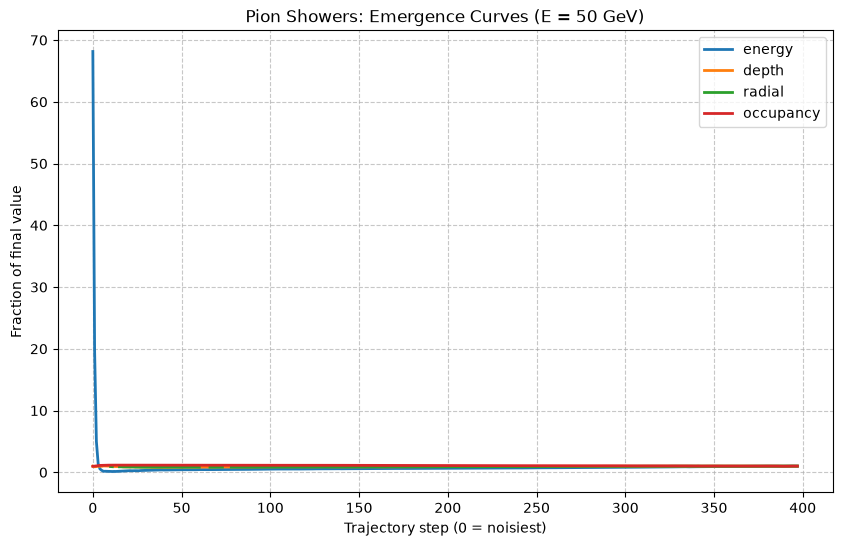

In [31]:
plt.figure(figsize=(10, 6))
for name, vals in master_results['pion'].items():
    norm_curve = np.array(vals) / vals[-1]
    plt.plot(norm_curve, label=name, linewidth=2)
    
plt.xlabel('Trajectory step (0 = noisiest)')
plt.ylabel('Fraction of final value')
plt.title('Pion Showers: Emergence Curves (E = 50 GeV)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Emergence_Curve-Pion[50GeV].png',dpi = 300)
plt.show()

## 3D Visualization of Particles



 Model: 

SAMPLE ALGO : ddpm
Time for sampling 1 events is 4.732585191726685 seconds
dset 2


 Model: 

SAMPLE ALGO : ddpm
Time for sampling 1 events is 5.149167537689209 seconds
dset 11


 Model: 

SAMPLE ALGO : ddpm
Time for sampling 1 events is 5.14952278137207 seconds
dset 10


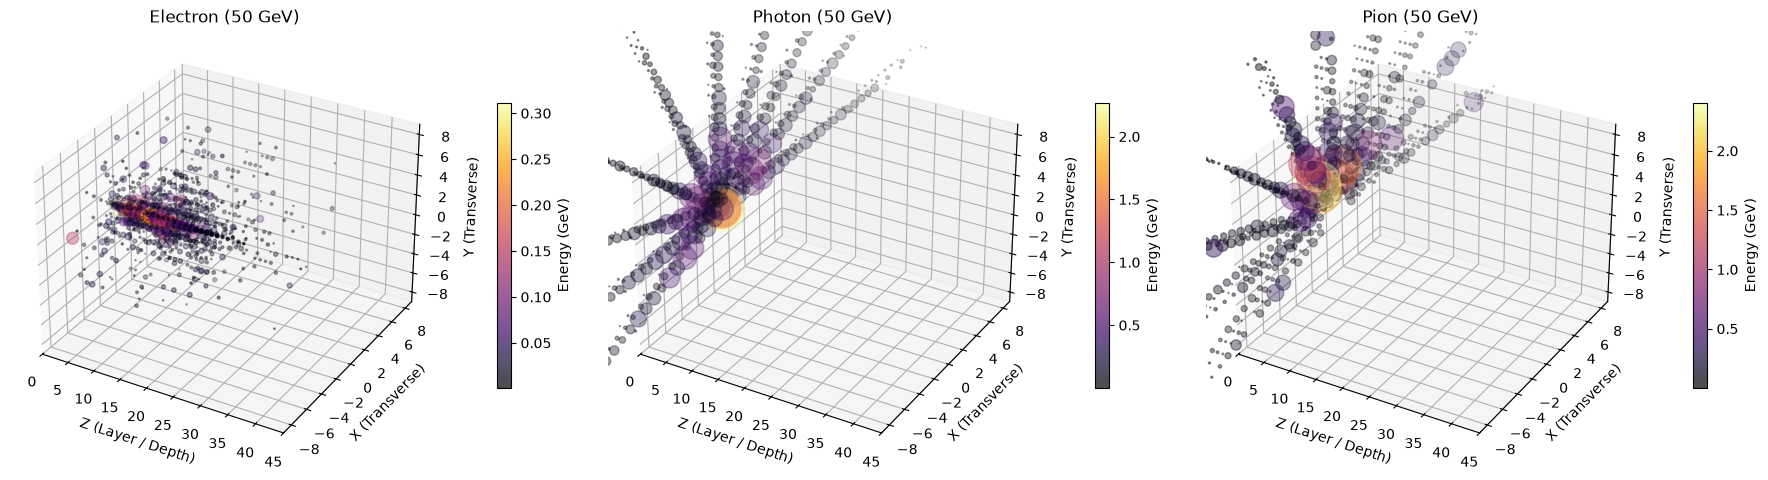

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def plot_3d_shower(ax, grid_3d, title):
    threshold = 0.001 
    layers, angles, rads = np.where(grid_3d > threshold)
    energies = grid_3d[layers, angles, rads]
    
    # Angles are in 16 bins. Convert to radians: (angle_bin / 16) * 2pi
    phi = (angles / 16.0) * 2 * np.pi
    
    # Radii are in 9 bins. 
    r = rads 
    
    # Z is the layer depth (longitudinal axis)
    z = layers
    
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    
    # Marker size and color map scaled by the energy in the voxel
    sc = ax.scatter(z, x, y, c=energies, s=energies*500, cmap='inferno', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('Z (Layer / Depth)')
    ax.set_ylabel('X (Transverse)')
    ax.set_zlabel('Y (Transverse)')
    ax.set_xlim(0, 45)
    ax.set_ylim(-9, 9)
    ax.set_zlim(-9, 9)
    
    return sc

fig = plt.figure(figsize=(18, 6))

for idx, particle in enumerate(['electron', 'photon', 'pion']):
    model = cp.load_model(particle)
    matched_energy = 50.0
    E_inc_gev = [matched_energy] * 1
    E_cond = cp.encode_energy(particle, E_inc_gev)
    _, _, x0s = cp.sample(model, E_cond, debug=True)
    final_x0 = x0s[-1]   # The clean, fully denoised shower
    
    raw_physical = cp.to_physical(model, final_x0, E_inc_gev)
    if particle in ['photon', 'pion']:
        g = cp.regular_grid(model, raw_physical)
    else:
        g = raw_physical
        
    single_shower = g[0]
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    sc = plot_3d_shower(ax, single_shower, f"{particle.capitalize()} (50 GeV)")
    fig.colorbar(sc, ax=ax, label='Energy (GeV)', shrink=0.5, pad=0.1)
plt.savefig('3-D_Visualization.png',dpi = 300)
plt.tight_layout()
plt.show()

### Longitudinal Profiles and Transverse Heatmaps for Clear Visualization 



 Model: 

SAMPLE ALGO : ddpm
Time for sampling 1 events is 4.732820510864258 seconds
dset 2


 Model: 

SAMPLE ALGO : ddpm
Time for sampling 1 events is 5.069267749786377 seconds
dset 11


 Model: 

SAMPLE ALGO : ddpm
Time for sampling 1 events is 5.212468862533569 seconds
dset 10


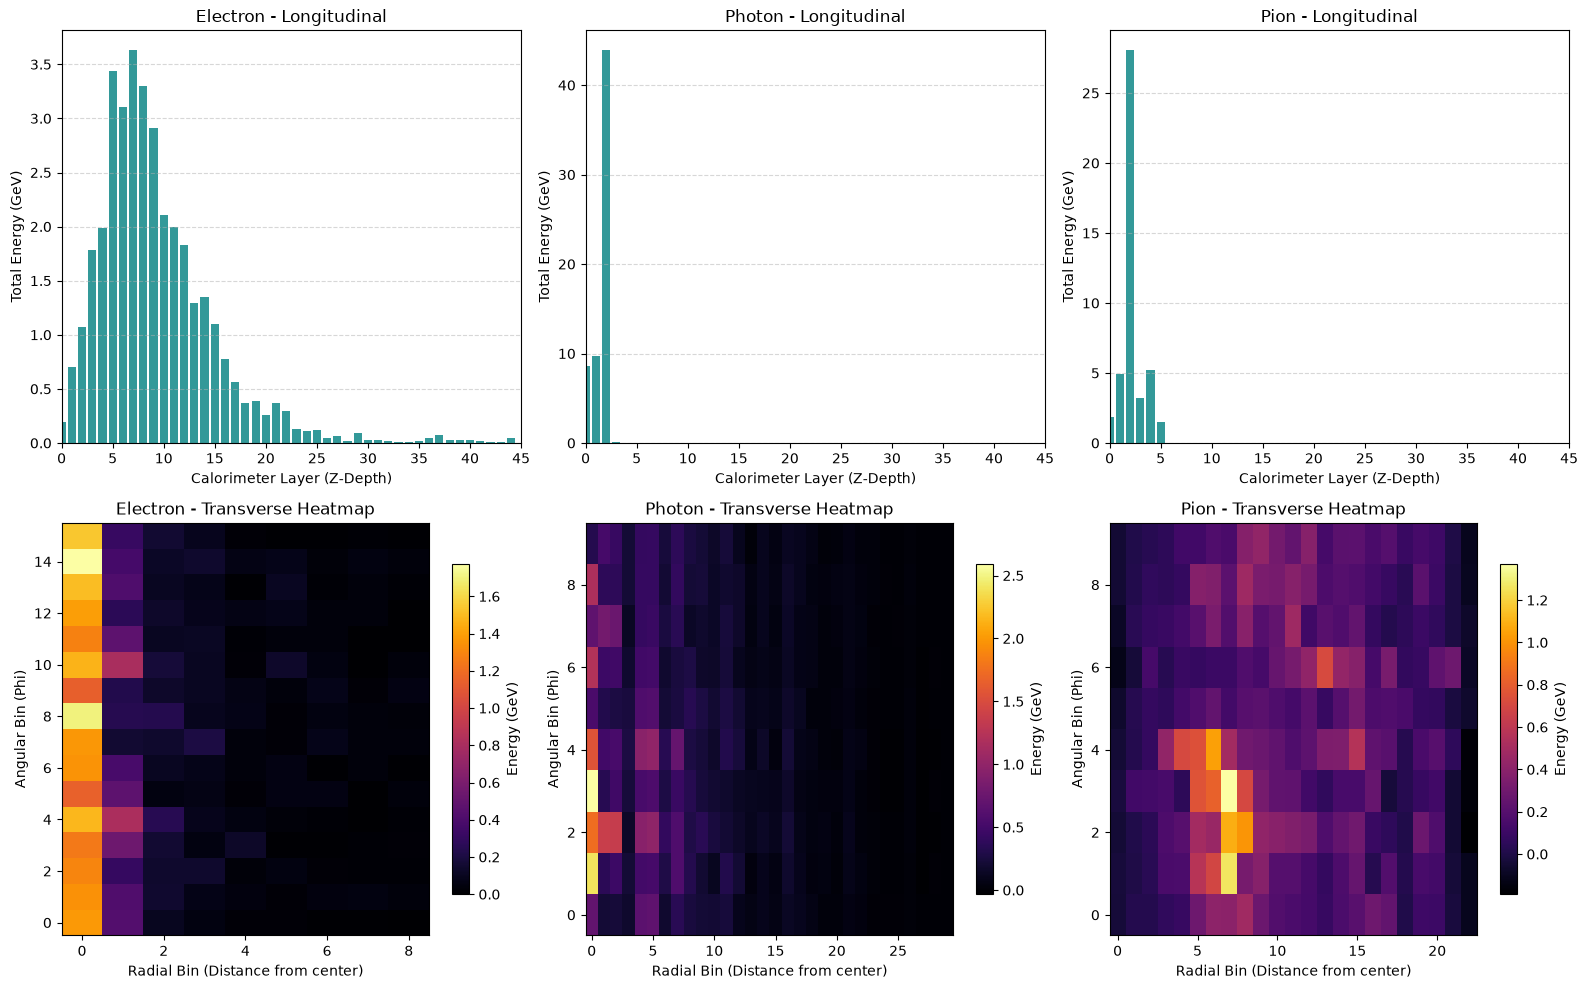

In [39]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
particles = ['electron', 'photon', 'pion']

for idx, particle in enumerate(particles):
    model = cp.load_model(particle)
    E_inc_gev = [50.0] * 1
    E_cond = cp.encode_energy(particle, E_inc_gev)
    
    _, _, x0s = cp.sample(model, E_cond, debug=True)
    
    final_x0 = x0s[-1]
    raw_physical = cp.to_physical(model, final_x0, E_inc_gev)
    
    if particle in ['photon', 'pion']:
        g = cp.regular_grid(model, raw_physical)
    else:
        g = raw_physical
        
    single_shower = g[0]  
    
    # Plot 1: Longitudinal Profile (Energy vs. Depth)
    ax_z = axes[0, idx]
    energy_per_layer = single_shower.sum(axis=(1, 2))
    layers = np.arange(len(energy_per_layer))
    
    ax_z.bar(layers, energy_per_layer, color='teal', alpha=0.8)
    ax_z.set_title(f"{particle.capitalize()} - Longitudinal")
    ax_z.set_xlabel("Calorimeter Layer (Z-Depth)")
    ax_z.set_ylabel("Total Energy (GeV)")
    ax_z.set_xlim(0, 45)
    ax_z.grid(True, axis='y', linestyle='--', alpha=0.5)

    # PLot 2: Transverse Heatmap (Angular vs. Radial)
    ax_xy = axes[1, idx]
    transverse_energy = single_shower.sum(axis=0) # Shape: (16, 9)
    
    im = ax_xy.imshow(transverse_energy, cmap='inferno', aspect='auto', origin='lower')
    ax_xy.set_title(f"{particle.capitalize()} - Transverse Heatmap")
    ax_xy.set_xlabel("Radial Bin (Distance from center)")
    ax_xy.set_ylabel("Angular Bin (Phi)")
    
    fig.colorbar(im, ax=ax_xy, label='Energy (GeV)', shrink=0.8)

plt.tight_layout()
plt.savefig('Longitudinal_Profiles_&_Transverse_Heatmaps.png',dpi = 300)
plt.show()

- We were supposed to look at the generative trajectory of the **CaloDiffusion** module, from pure noise to a fully realized physical state.
- We try and isolate exactly when and how the module **resolves physical properties of simulated showers**.
- We try to analyze by comparing the **Electromagnetic (Electrons and Photons)** particles and **Hadronic(Pions)** particle showers across different simulated detector geometries i.e **Dataset 1 has Photons and Pions with 368 total voxels** which has lower resolution, coarse, irregular and geometry inspired from **ATLAS** and **Dataset 2 has Electrons with 6,480 total voxels** with higher resolution, fine, highly segmented and uses a **regular cylindrical grid**.

# Observations :

### Electron
- We observe that **Depth** was locked in at **106th** denoising step, **Radial Spread** at **239th**, **Energy** at **300th** and **Occupancy** at **307th** step.
- The model establishes the coarse, macro-geometry (Depth) nearly 200 steps before finalizing sparse micro-details (Occupancy).
- This proves that high-resolution detector grids demand immense denoising time to resolve fine structure and **proves the COARSE-TO-FINE-TRAJECTORY hypothesis true.**

### Photon
- We observe that **Depth** was locked in at **3rd** denoising step, **Radial Spread** at **1st**, **Energy** at **273rd** and **Occupancy** at **1st** step.
- Proves that coarse detector geometry eliminates the fine-structure delay for simple shapes.
- Confined to a low-resolution grid, the model bypasses the typical denoising timeline and deposits the compact electromagnetic shape into a few massive bins almost instantly.

### Pion
- We observe that **Depth** was locked in at **179th** denoising step, **Radial Spread** at **216th**, **Energy** at **340** and **Occupancy** at **201st** step.
- Confirms that highly fluctuating, messy hadronic physics delays generation.
- Even while using the exact same low-resolution grid as the photon, the pion required large additional steps just to establish its macro-depth, proving that complex particle interactions inherently stretch the coarse-to-fine gap.

## Inferences for now :

### The Coarse-to-Fine Generative Mechanism
The observation **confirms** that diffusion models inherently construct physical data in a **coarse-to-fine order**. **By measuring the lock-in step**, which is the point in the generation trajectory where an observable stabilizes within a 10% tolerance of its final physical value **we see a clear temporal hierarchy**. Macro-level geometric structures, like longitudinal shower **depth, are resolved early during denoising process**. In contrast, **sparse and highly detailed micro-structures, specifically the exact voxel occupancy and radial spread, require nearly the entire trajectory to stabilize**. The **model establishes the broad strokes of the energy deposition before fine-tuning the exact boundaries**.

### The Hadronic Complexity Gap
Comparing the emergence curves of photons and pions within the same irregular, coarse detector geometry (Dataset 1) shows us that the **internal complexity of the particle directly influences the generation timeline**. **Electromagnetic showers (photons), which are compact and highly predictable, achieved structural lock-in almost instantaneously**. Conversely, **hadronic showers (pions)**, known for deep, messy, and violently fluctuating energy deposits, **severely delayed the model's ability to resolve fine structure**. The pion required significantly more denoising steps to finalize its radial spread and occupancy, proving that the **coarse-to-fine temporal gap widens substantially when the model is forced to reconstruct complex, fluctuating hadronic physics**.

### The Detector Resolution Effect
**A cross-dataset comparison between electrons (Dataset 2: 6,480 uniform voxels) and photons (Dataset 1: 368 irregular voxels) isolated the effect of detector granularity on the generative process**. Despite both being electromagnetic particles with nearly identical underlying physical shower shapes, their lock-in steps varied drastically. **The low-resolution photon locked in its spatial observables immediately**. **The high-resolution electron required over 300 steps to achieve occupancy lock-in. This indicates that the delayed emergence of "fine structure" is heavily bottlenecked by the spatial resolution of the detector grid**.

---
## 3 · Where to go next

- **Nice-to-have (the headline):** repeat §2 for `'photon'` and `'pion'` at *matched* energies.
  Does the coarse→fine gap **widen** for the messy hadronic pion showers? → Table 2, Fig 3.
- **Optional (pick one, with us):** spectral emergence (azimuthal FFT, electron only) /
  conditioning intervention / a linear probe inside the U-Net. See `JUMPING_OFF_POINTS.md`.

Deliverables, milestones, and what's *out* of scope are all in `JUMPING_OFF_POINTS.md`.